# Downloading Libraries

In [3]:
! pip install nltk
! pip install vaderSentiment
! pip install pytrends
! pip install textblob
! pip install wordcloud
! pip install gensim
! pip install seaborn
! pip install TextBlob
! pip install joblib
! pip install xgboost

# Importing Libraries

In [5]:
import nltk
import logging
import numpy as np
import pandas as pd
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.preprocessing import LabelEncoder


from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import joblib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [6]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet', quiet=True)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/bishanbhandari/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bishanbhandari/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Importing Dataset

In [8]:
df = pd.read_csv('Dataset/Cleaned Data/Cleaned_reviews.csv')
df.head()

,date,reviewer_name,comments,cleaned_comments,polarity,sentiment
0,2024-05-21,Janice,"This was our second stay at this Airbnb, and c...","second stay airbnb, certainli last. locat conv...",0.094444,negative
1,2024-09-03,Jose Maria,Adorei minha hospedagem com Earl. Foi fácil me...,adorei minha hospedagem com earl. foi fácil co...,0.000000,negative
2,2024-10-31,Casey,Would certainly stay here again.,would certainli stay again.,0.000000,negative
3,2022-10-07,Erin,"5 stars, it was exactly as I expected. I hope ...","5 stars, exactli expected. hope stay come back...",-0.033333,negative
4,2025-11-30,Fırat,We had a wonderful stay .,wonder stay .,0.000000,negative


# Data Preprocessing

In [10]:
df.isnull().sum()

date                 0
reviewer_name        0
comments             8
cleaned_comments    95
polarity             0
sentiment            0
dtype: int64

# Expolratory Data Analysis

In [12]:
reviewer_freq=df['reviewer_name'].value_counts()
print(reviewer_freq)

reviewer_name
Michael    131
John        98
Daniel      92
David       91
Sarah       78
          ... 
Dayna        1
Tayvhon      1
Karma        1
Yolanda      1
Irvelyn      1
Name: count, Length: 4153, dtype: int64


<Figure size 1000x800 with 0 Axes>

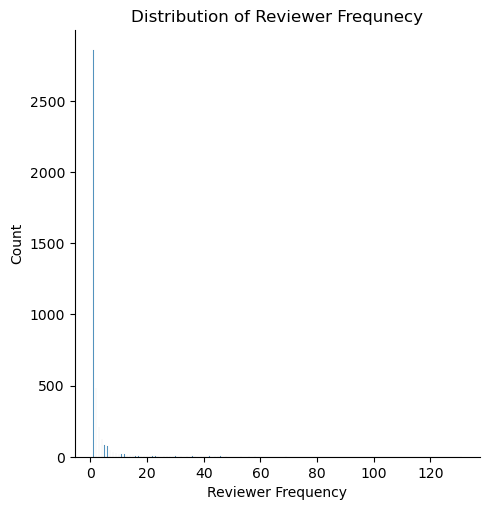

In [13]:
# plot the distribution of reviewer frequency using seaborn
plt.figure(figsize=(10,8))
sns.displot(reviewer_freq,kde=False)
plt.title('Distribution of Reviewer Frequnecy')
plt.xlabel('Reviewer Frequency')
plt.ylabel('Count')
plt.show()

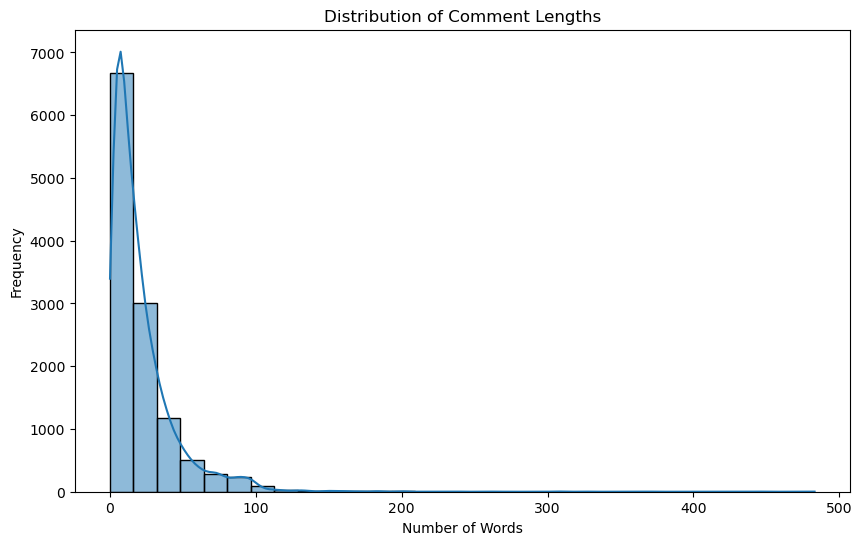

In [14]:
df['comment_length']=df['cleaned_comments'].fillna(' ').apply(lambda x:len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=30, kde=True)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

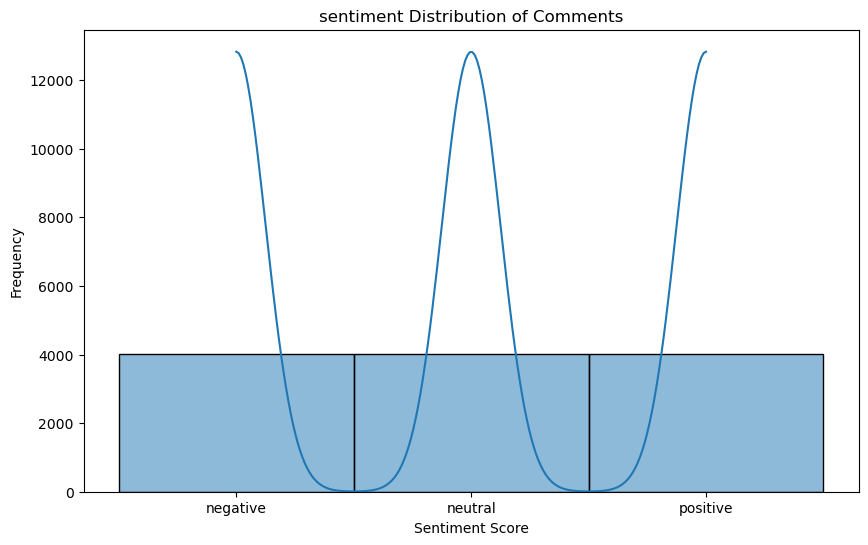

In [15]:
# Sentimetn Distribution of comments
plt.figure(figsize=(10,6))
sns.histplot(df['sentiment'],bins=30,kde=True)
plt.title('sentiment Distribution of Comments')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

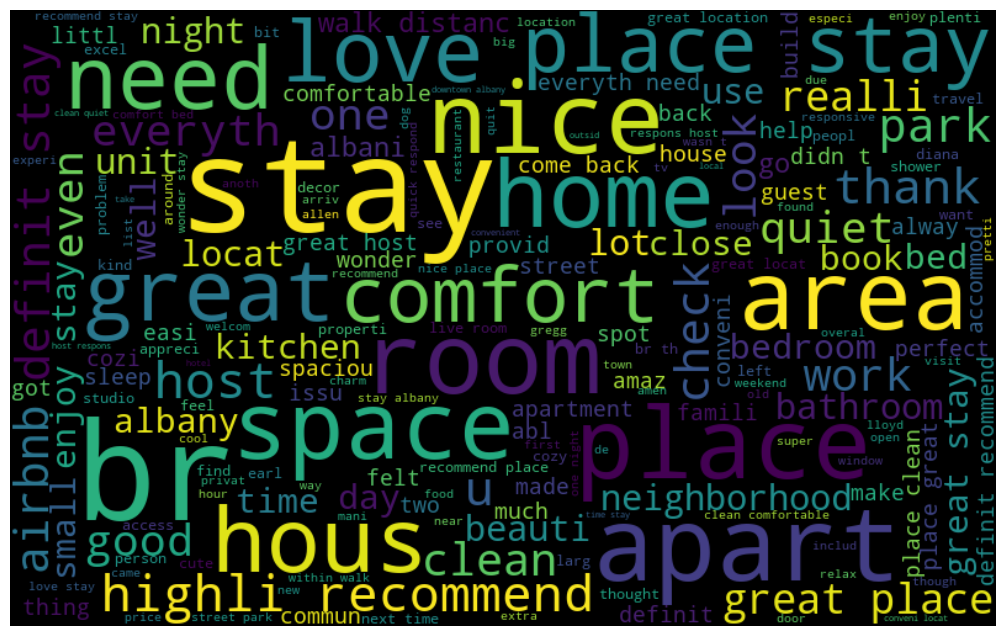

In [16]:
# Word Frequency Analysis
# Display the word that appear frequently
all_words = ' '.join(df['cleaned_comments'].dropna())
wordcloud=WordCloud(width=800,height=500,random_state=21,
                   max_font_size=110).generate(all_words)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis('off')
plt.show()

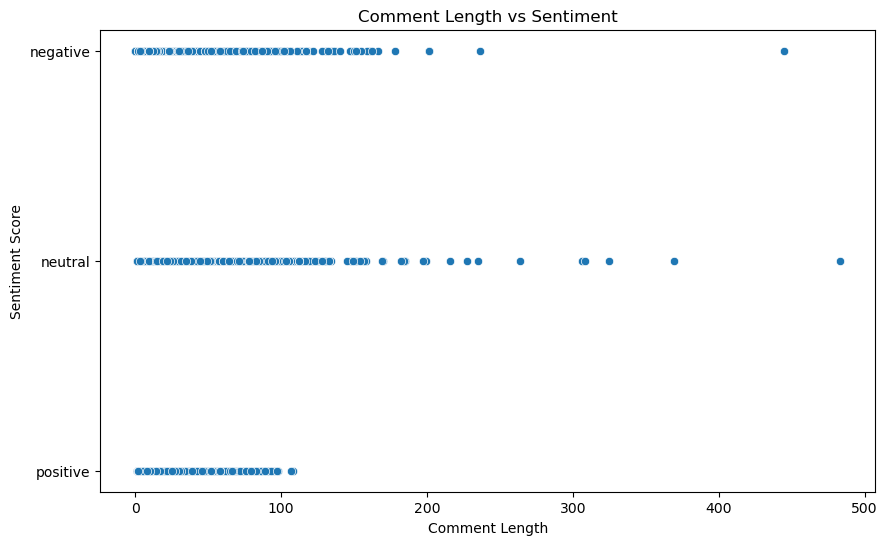

In [17]:
# Comment Length vs Sentiment
plt.figure(figsize=(10, 6))
sns.scatterplot(x='comment_length', y='sentiment', data=df)
plt.title('Comment Length vs Sentiment')
plt.xlabel('Comment Length')
plt.ylabel('Sentiment Score')
plt.show()

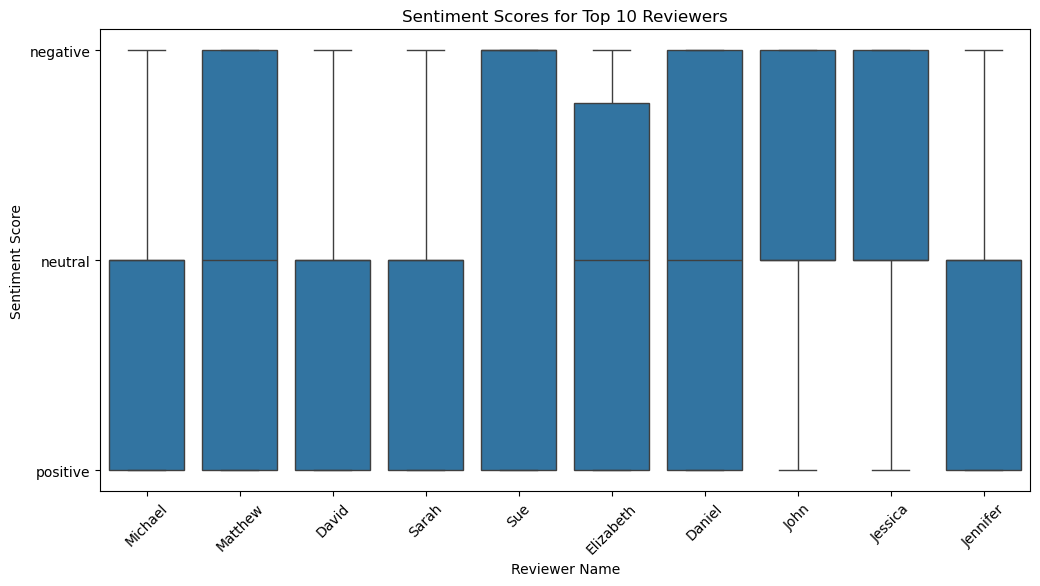

In [18]:
# Reviewer Frequency and Sentiment 
# Top 10 reviewers
top_reviewers=df['reviewer_name'].value_counts().head(10).index # index=return name only
top_reviewers_df=df[df['reviewer_name'].isin(top_reviewers)]

plt.figure(figsize=(12,6))
sns.boxplot(x='reviewer_name',y='sentiment',data=top_reviewers_df)
plt.xticks(rotation=45)
plt.title('Sentiment Scores for Top 10 Reviewers')
plt.xlabel('Reviewer Name')
plt.ylabel('Sentiment Score')
plt.show()

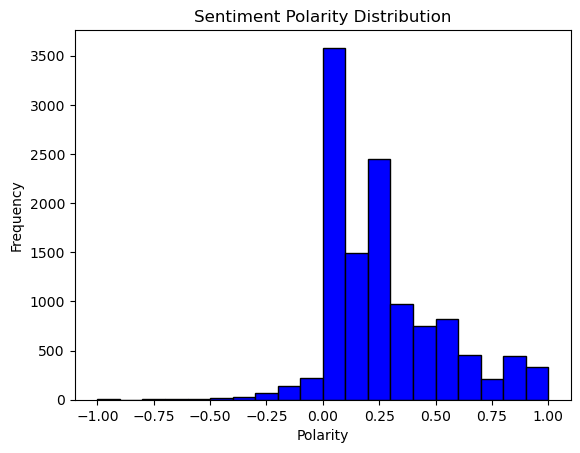

In [19]:
# Plot histogram
plt.hist(df['polarity'],bins=20,color='blue',edgecolor='black')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.show()

# Assessment : Experimentations (Using Maxhine Learning)

In [21]:
# Vectorization
df['cleaned_comments'] = df['cleaned_comments'].fillna('')
vectorizer=TfidfVectorizer()
X=vectorizer.fit_transform(df['cleaned_comments'])

In [22]:
# Split Dataset
X_train,X_test,y_train,y_test=train_test_split(
    X,df['sentiment'],test_size=0.2,random_state=42
)

In [23]:
print('Features X_train:')
X_train

Features X_train:


<9624x12445 sparse matrix of type '<class 'numpy.float64'>'
	with 187929 stored elements in Compressed Sparse Row format>

In [24]:
print("Features X_test:")
X_test

Features X_test:


<2406x12445 sparse matrix of type '<class 'numpy.float64'>'
	with 48491 stored elements in Compressed Sparse Row format>

In [25]:
print("Features y_train:")
y_train

Features y_train:


5875      neutral
3562     negative
3003     negative
2140     negative
9791     positive
           ...   
11964    positive
5191      neutral
5390      neutral
860      negative
7270      neutral
Name: sentiment, Length: 9624, dtype: object

In [26]:
print("Features y_test:")
y_test

Features y_test:


4412      neutral
10472    positive
5032      neutral
2611     negative
1562     negative
           ...   
3573     negative
3206     negative
5718      neutral
11319    positive
735      negative
Name: sentiment, Length: 2406, dtype: object

# Logistic Regression

In [28]:
print("Evaluation for: Logistic Regression Classifier".center(80, '_'))
lgc=LogisticRegression()
lgc.fit(X_train,y_train)

lgc_pred = lgc.predict(X_test)
lgc_acc = accuracy_score(y_test, lgc_pred)
lgc_prec = precision_score(y_test, lgc_pred, average='weighted')
lgc_rec = recall_score(y_test, lgc_pred, average='weighted')
lgc_f1 = f1_score(y_test, lgc_pred, average='weighted')

print(f"Model Type: {lgc}")
print("\n" + f"Prediciton: {lgc_pred}")
print('-' * 80)

print(f"Accuracy Score:  {(lgc_acc):%}")
print(f"Precision Score: {(lgc_prec):%}")
print(f"Recall Score:    {(lgc_rec):%}")
print(f"F1-Score:        {(lgc_f1):%}")

_________________Evaluation for: Logistic Regression Classifier_________________
Model Type: LogisticRegression()

Prediciton: ['neutral' 'positive' 'negative' ... 'neutral' 'positive' 'negative']
--------------------------------------------------------------------------------
Accuracy Score:  81.878637%
Precision Score: 82.356759%
Recall Score:    81.878637%
F1-Score:        81.987014%


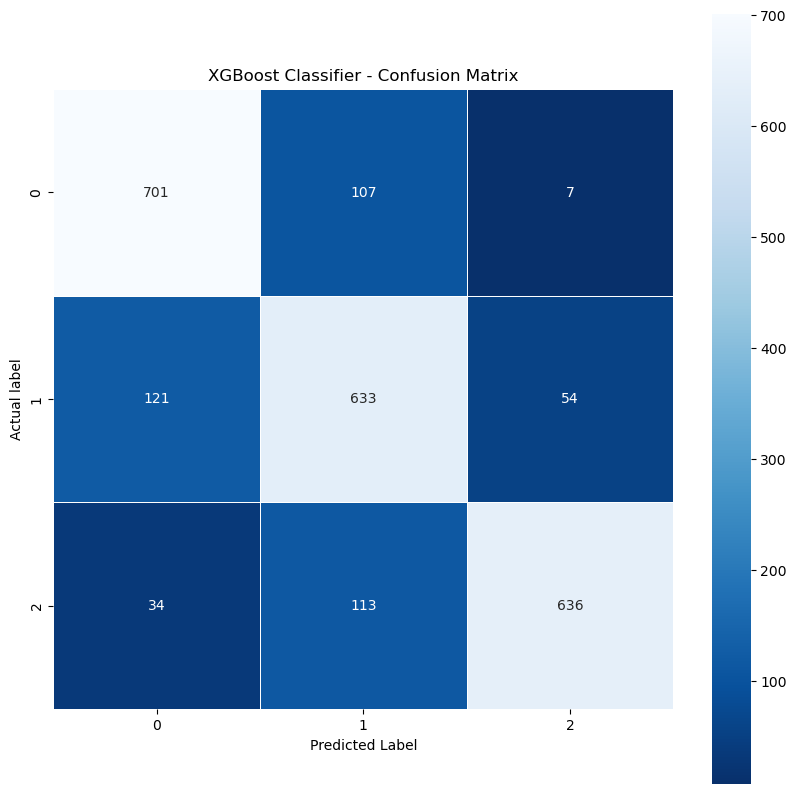

In [29]:
# Plotting the Confusion Matrix
lgc_confusion_matrix=confusion_matrix(y_test,lgc_pred)

plt.figure(figsize=(10,10))
sns.heatmap(lgc_confusion_matrix,annot=True,fmt=".0f",
             linewidths=0.7,square=True,cmap='Blues_r')
plt.ylabel("Actual label")
plt.xlabel("Predicted Label")
plt.title("XGBoost Classifier - Confusion Matrix")
plt.show()

In [30]:
print("Classification Report For XGBoost Classifier:")
print('-' * 57)
print(classification_report(y_test,lgc_pred))

Classification Report For XGBoost Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84       815
     neutral       0.74      0.78      0.76       808
    positive       0.91      0.81      0.86       783

    accuracy                           0.82      2406
   macro avg       0.82      0.82      0.82      2406
weighted avg       0.82      0.82      0.82      2406



In [31]:
# save the logistic regression model
joblib.dump(lgc, 'Models/logistic_regression_model.pkl')

['Models/logistic_regression_model.pkl']

In [32]:
# save the vectorizer
joblib.dump(vectorizer, 'Models/tfidf_vectorizer.pkl')

['Models/tfidf_vectorizer.pkl']

# AdaBoost Classifier

In [34]:
print("Evaluation for: AdaBoost Classifier".center(57, '_'))
abc=AdaBoostClassifier()

abc.fit(X_train,y_train)

abc_prediction=abc.predict(X_test)

abc_accuracy_score = accuracy_score(y_test, abc_prediction)
abc_precision_score = precision_score(
    y_test, abc_prediction, average="weighted")
abc_recall_score = recall_score(y_test, abc_prediction, average="weighted")
abc_f1_score = f1_score(y_test, abc_prediction, average="weighted")

print(f"Model Type: {abc}")
print(f"Prediciton: {abc_prediction}")
print('-' * 57)

print(f"Accuracy Score:  {(abc_accuracy_score):%}")
print(f"Precision Score: {(abc_precision_score):%}")
print(f"Recall Score:    {(abc_recall_score):%}")
print(f"F1-Score:        {(abc_f1_score):%}")

___________Evaluation for: AdaBoost Classifier___________
Model Type: AdaBoostClassifier()
Prediciton: ['negative' 'positive' 'negative' ... 'neutral' 'neutral' 'negative']
---------------------------------------------------------
Accuracy Score:  68.121363%
Precision Score: 69.958819%
Recall Score:    68.121363%
F1-Score:        67.527592%


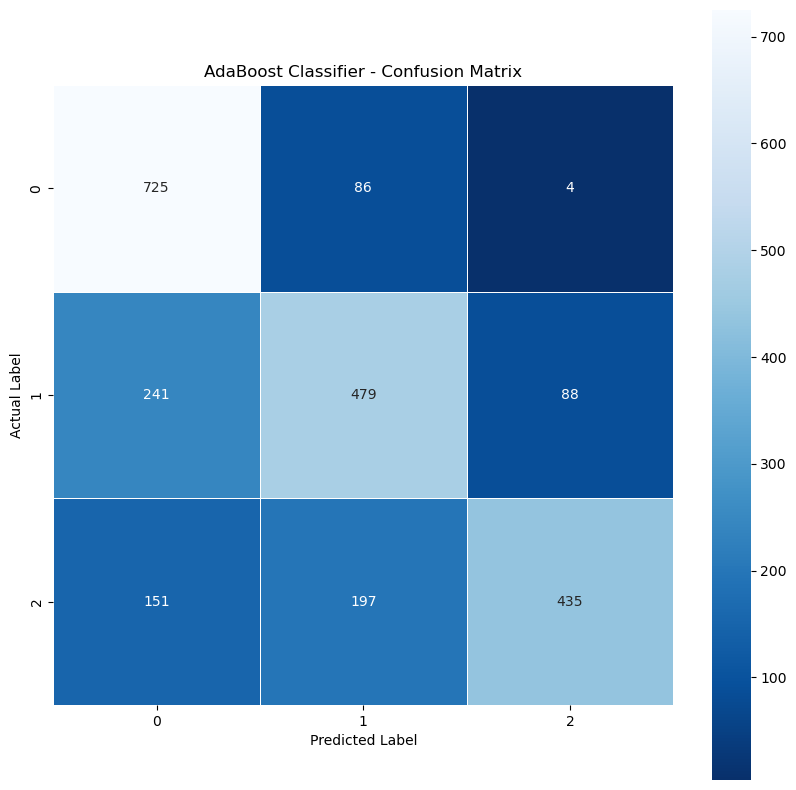

In [35]:
# Plotting the confusion matrix
abc_confusion_matrix=confusion_matrix(y_test,abc_prediction)

plt.figure(figsize=(10,10))
sns.heatmap(abc_confusion_matrix,annot=True,fmt=".0f",linewidths=0.7,square=True,cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("AdaBoost Classifier - Confusion Matrix")
plt.show()

In [36]:
print("Classification Report For AdaBoost Classifier:")
print('-' * 57)
print(classification_report(y_test,abc_prediction))

Classification Report For AdaBoost Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.65      0.89      0.75       815
     neutral       0.63      0.59      0.61       808
    positive       0.83      0.56      0.66       783

    accuracy                           0.68      2406
   macro avg       0.70      0.68      0.67      2406
weighted avg       0.70      0.68      0.68      2406



In [37]:
# save the logistic regression model
joblib.dump(abc, 'Models/ada_boost_model.pkl')

['Models/ada_boost_model.pkl']

# K-Nearest Neighbors

In [39]:
print("Evaluation for: K-Neighbors Classifier".center(57, '_'))

knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

knn_prediction=knn.predict(X_test)
knn_accuracy_score=accuracy_score(y_test,knn_prediction)
knn_precision_score = precision_score(
    y_test, knn_prediction, average="weighted")
knn_recall_score = recall_score(y_test, knn_prediction, average="weighted")
knn_f1_score = f1_score(y_test, knn_prediction, average="weighted")

print(f"Model Type: {knn}")
print(f"Prediciton: {knn_prediction}")
print('-' * 57)

print(f"Accuracy Score:  {(knn_accuracy_score):%}")
print(f"Precision Score: {(knn_precision_score):%}")
print(f"Recall Score:    {(knn_recall_score):%}")
print(f"F1-Score:        {(knn_f1_score):%}")

__________Evaluation for: K-Neighbors Classifier_________
Model Type: KNeighborsClassifier()
Prediciton: ['negative' 'positive' 'negative' ... 'neutral' 'negative' 'negative']
---------------------------------------------------------
Accuracy Score:  38.445553%
Precision Score: 61.235473%
Recall Score:    38.445553%
F1-Score:        26.998657%


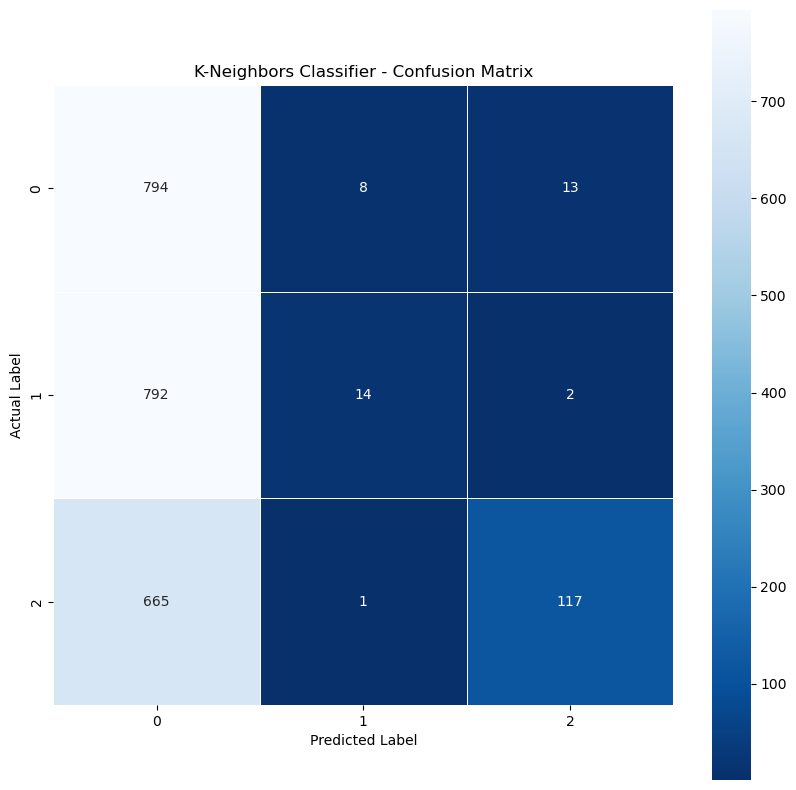

In [40]:
# Plotting  the Confusion Matrix:
knn_confusion_matrix=confusion_matrix(y_test,knn_prediction)
plt.figure(figsize=(10, 10))
sns.heatmap(knn_confusion_matrix, annot=True, fmt=".0f",
            linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("K-Neighbors Classifier - Confusion Matrix")
plt.show()

In [41]:
print("Classification Report For K-Neighbors Classifier:")
print('-' * 57)
print(classification_report(y_test,knn_prediction))

Classification Report For K-Neighbors Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.35      0.97      0.52       815
     neutral       0.61      0.02      0.03       808
    positive       0.89      0.15      0.26       783

    accuracy                           0.38      2406
   macro avg       0.62      0.38      0.27      2406
weighted avg       0.61      0.38      0.27      2406



In [42]:
# save the k-neighbors model
joblib.dump(knn, 'Models/k_neighbors_model.pkl')

['Models/k_neighbors_model.pkl']

#  Decision Tree Classifier

In [44]:
print("Evaluation for: Decision Tree Classifier".center(57, '_'))

dtc=DecisionTreeClassifier()

dtc.fit(X_train,y_train)
dtc_prediction=dtc.predict(X_test)
dtc_accuracy_score=accuracy_score(y_test,dtc_prediction)
dtc_precision_score = precision_score(
    y_test, dtc_prediction, average="weighted")
dtc_recall_score = recall_score(y_test, dtc_prediction, average="weighted")
dtc_f1_score = f1_score(y_test, dtc_prediction, average="weighted")

print(f"Model Type: {dtc}")
print(f"Prediciton: {dtc_prediction}")
print('-' * 57)

print(f"Accuracy Score:  {(dtc_accuracy_score):%}")
print(f"Precision Score: {(dtc_precision_score):%}")
print(f"Recall Score:    {(dtc_recall_score):%}")
print(f"F1-Score:        {(dtc_f1_score):%}")

_________Evaluation for: Decision Tree Classifier________
Model Type: DecisionTreeClassifier()
Prediciton: ['negative' 'positive' 'positive' ... 'negative' 'negative' 'negative']
---------------------------------------------------------
Accuracy Score:  74.729842%
Precision Score: 74.808597%
Recall Score:    74.729842%
F1-Score:        74.767295%


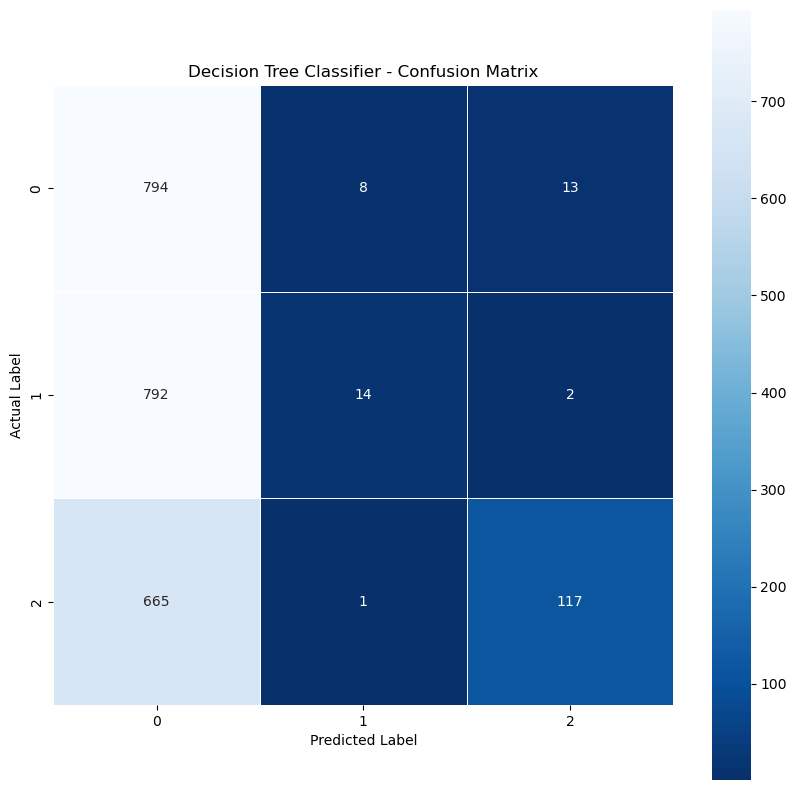

In [45]:
# Plotting the Confusion Matrix:
dtc_confusion_matrix = confusion_matrix(y_test,knn_prediction)

plt.figure(figsize=(10, 10))
sns.heatmap(dtc_confusion_matrix, annot=True, fmt=".0f",
            linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("Decision Tree Classifier - Confusion Matrix")
plt.show()

In [46]:
print("Classification Report For Decision Tree Classifier:")
print('-' * 57)
print(classification_report(y_test, dtc_prediction))

Classification Report For Decision Tree Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.85      0.84      0.84       815
     neutral       0.66      0.66      0.66       808
    positive       0.74      0.74      0.74       783

    accuracy                           0.75      2406
   macro avg       0.75      0.75      0.75      2406
weighted avg       0.75      0.75      0.75      2406



In [47]:
# save the decision tree model
joblib.dump(dtc, 'Models/decision_tree_model.pkl')

['Models/decision_tree_model.pkl']

# Random Forest Classifier

In [86]:
print("Evaluation for: Random Forest Classifier".center(57, '_'))
rfc=RandomForestClassifier()

rfc.fit(X_train,y_train)

rfc_prediction=rfc.predict(X_test)
rfc_accuracy_score=accuracy_score(rfc_prediction,y_test)
rfc_precision_score = precision_score(
    y_test, rfc_prediction, average="weighted")
rfc_recall_score = recall_score(y_test, rfc_prediction, average="weighted")
rfc_f1_score = f1_score(y_test, rfc_prediction, average="weighted")

print(f"Model Type: {rfc}")
print(f"Prediciton: {rfc_prediction}")
print('-' * 57)

print(f"Accuracy Score:  {(rfc_accuracy_score):%}")
print(f"Precision Score: {(rfc_precision_score):%}")
print(f"Recall Score:    {(rfc_recall_score):%}")
print(f"F1-Score:        {(rfc_f1_score):%}")

_________Evaluation for: Random Forest Classifier________
Model Type: RandomForestClassifier()
Prediciton: ['neutral' 'positive' 'negative' ... 'neutral' 'positive' 'negative']
---------------------------------------------------------
Accuracy Score:  76.475478%
Precision Score: 77.750031%
Recall Score:    76.475478%
F1-Score:        76.801598%


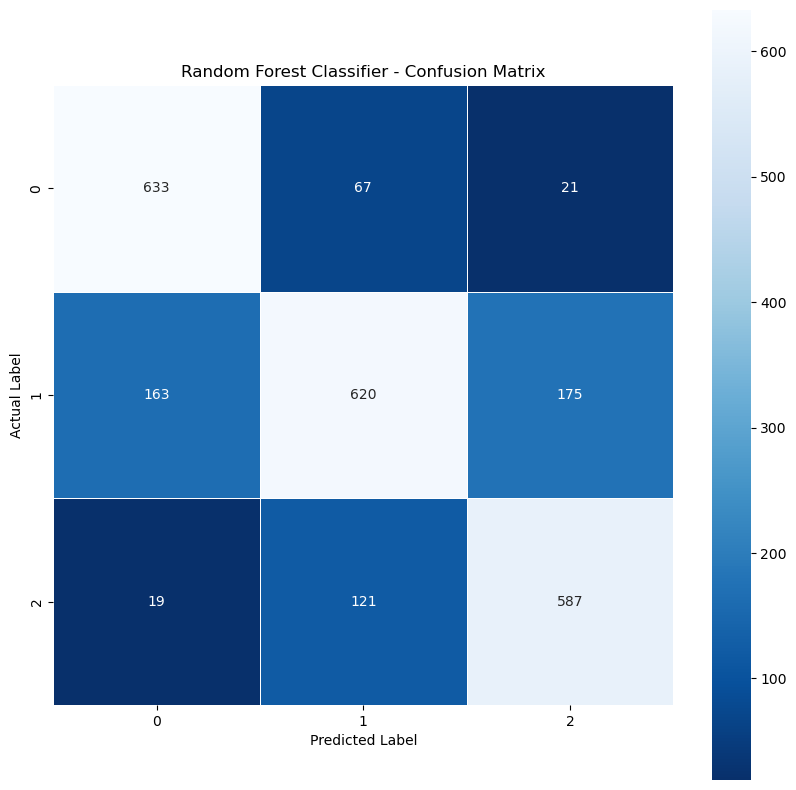

In [88]:
# Plotting the confusion matrix
rfc_confusion_matrix=confusion_matrix(rfc_prediction,y_test)
plt.figure(figsize=(10, 10))
sns.heatmap(rfc_confusion_matrix, annot=True, fmt=".0f",
            linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("Random Forest Classifier - Confusion Matrix")
plt.show()

In [90]:
print("Classification Report For Random Forest Classifier:")
print('-' * 57)
print(classification_report(y_test, rfc_prediction))

Classification Report For Random Forest Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.88      0.78      0.82       815
     neutral       0.65      0.77      0.70       808
    positive       0.81      0.75      0.78       783

    accuracy                           0.76      2406
   macro avg       0.78      0.76      0.77      2406
weighted avg       0.78      0.76      0.77      2406



In [92]:
# save the random forest model
joblib.dump(rfc, 'Models/random_forest_model.pkl')

['Models/random_forest_model.pkl']

# Gradient Boosting Classifier

In [95]:
print("Evaluation for: Gradient Boosting Classifier".center(57, '_'))

gbc = GradientBoostingClassifier()

gbc.fit(X_train, y_train)

gbc_prediction = gbc.predict(X_test)
gbc_accuracy_score = accuracy_score(y_test, gbc_prediction)
gbc_precision_score = precision_score(
    y_test, gbc_prediction, average="weighted")
gbc_recall_score = recall_score(y_test, gbc_prediction, average="weighted")
gbc_f1_score = f1_score(y_test, gbc_prediction, average="weighted")

print(f"Model Type: {gbc}")
print(f"Prediciton: {gbc_prediction}")
print('-' * 57)

print(f"Accuracy Score:  {(gbc_accuracy_score):%}")
print(f"Precision Score: {(gbc_precision_score):%}")
print(f"Recall Score:    {(gbc_recall_score):%}")
print(f"F1-Score:        {(gbc_f1_score):%}")

_______Evaluation for: Gradient Boosting Classifier______
Model Type: GradientBoostingClassifier()
Prediciton: ['neutral' 'positive' 'negative' ... 'neutral' 'positive' 'negative']
---------------------------------------------------------
Accuracy Score:  79.010806%
Precision Score: 79.230869%
Recall Score:    79.010806%
F1-Score:        78.933198%
